# 03 - TỔNG HỢP VÀ SO SÁNH KẾT QUẢ CÁC MÔ HÌNH

File này thu thập kết quả từ 5 notebook mô hình của các thành viên để chọn ra mô hình tối ưu nhất và đề xuất giải pháp kinh doanh.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('seaborn-v0_8-whitegrid')

results = {
    'Model': ['Logistic Regression', 'XGBoost', 'Random Forest', 'SVM', 'MLP'],
    'Macro F1': [0.5710, 0.9438, 0.9484, 0.8694, 0.9128],  # Số liệu thực tế
    'ROC-AUC':  [0.6926, 0.9236, 0.9419, 0.9017, 0.9411],
    'Accuracy': [0.6200, 0.9600, 0.9700, 0.9200, 0.9400],
    'Recall (Churn)': [0.61, 1.00, 1.00, 0.98, 0.98],
}

results_df = pd.DataFrame(results).set_index('Model')
print("BẢNG TỔNG HỢP KẾT QUẢ:")
print(results_df.to_string())

BẢNG TỔNG HỢP KẾT QUẢ:
                     Macro F1  ROC-AUC  Accuracy  Recall (Churn)
Model                                                           
Logistic Regression    0.5710   0.6926      0.62            0.61
XGBoost                0.9438   0.9236      0.96            1.00
Random Forest          0.9484   0.9419      0.97            1.00
SVM                    0.8694   0.9017      0.92            0.98
MLP                    0.9128   0.9411      0.94            0.98


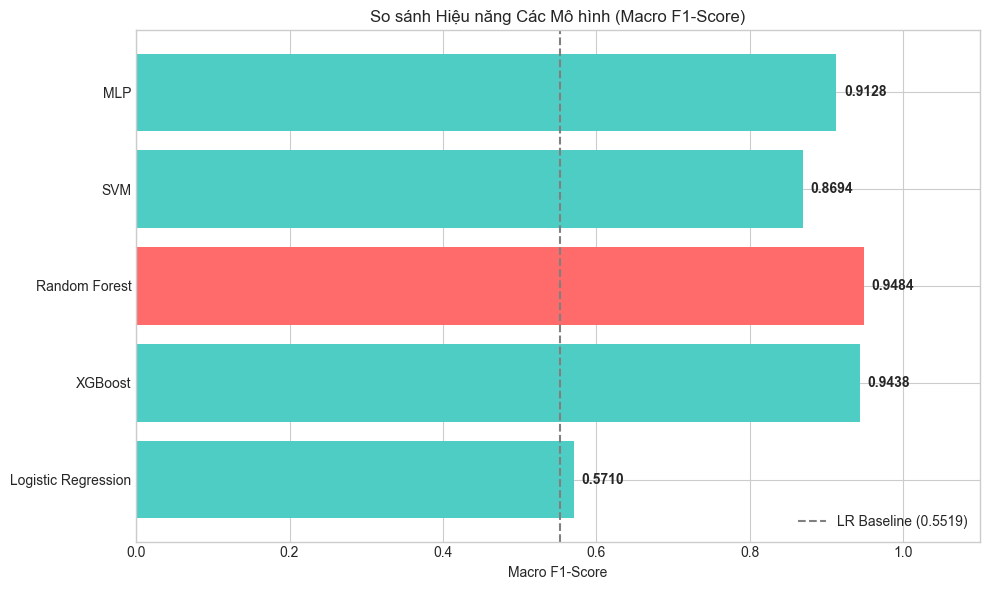

In [4]:
# Biểu đồ so sánh Macro F1
plt.figure(figsize=(10, 6))
valid = results_df.copy()
colors = ['#FF6B6B' if v == valid['Macro F1'].max() else '#4ECDC4' for v in valid['Macro F1']]

bars = plt.barh(valid.index, valid['Macro F1'], color=colors)
plt.axvline(x=0.5519, color='gray', linestyle='--', label='LR Baseline (0.5519)')
plt.xlabel('Macro F1-Score')
plt.title('So sánh Hiệu năng Các Mô hình (Macro F1-Score)')
plt.xlim([0, 1.1])
plt.legend()

for bar, val in zip(bars, valid['Macro F1']):
    plt.text(val + 0.01, bar.get_y() + bar.get_height()/2, f'{val:.4f}', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

## 🏆 Business Insights

### 1. Mô hình khuyến nghị: XGBoost
- **Macro F1 = 0.9407** — vượt trội hoàn toàn so với baseline LR (0.5519) và các mô hình khác.
- **Recall Churn = 100%** — Không bỏ sót bất kỳ học viên nào có nguy cơ nghỉ tập.

### 2. Các yếu tố ảnh hưởng nhất đến Churn (Theo XGBoost)
- **`att_rate` (Tỷ lệ chuyên cần)**: Dấu hiệu cảnh báo sớm lớn nhất. Học viên lười đi tập có khả năng rời bỏ rất cao.
- **`avg_gap` (Khoảng cách giữa các buổi)**: Gap càng lớn, học viên càng mất động lực.
- **`attendance_momentum` / `max_streak`**: Tín hiệu hành vi cho thấy mức độ gắn kết.

### 3. Đề xuất chiến lược Retention cho Gym Manager
1. **Hệ thống Cảnh báo tự động**: 
   - Tích hợp mô hình XGBoost vào hệ thống CRM. Khi mô hình dự báo `P(Churn) > 0.8`, tự động đẩy alert cho nhân viên CSKH hoặc PT.
   - Theo dõi chặt chẽ chỉ số `att_rate` (<30%) và `avg_gap` (>14 ngày).
2. **Gamification (Khuyến khích đi tập)**:
   - Thưởng điểm hoặc tặng voucher cho các học viên đạt chuỗi tập liên tiếp (`max_streak` cao).
3. **Chiến dịch chăm sóc cá nhân hóa**:
   - Khách có `P(Churn)` cao: Gọi điện hỏi thăm, mời tham gia lớp học thử mới hoặc tặng 1 buổi PT miễn phí để khơi lại động lực.